# RAG Retrieval Evaluation and Failure Diagnosis

This notebook evaluates retrieval quality using files in `backend/evaluation` and helps identify which retrieval stage is causing errors.

## Sections
1. Environment Setup and Imports
2. Load Evaluation Data from `backend/evaluation`
3. Construct Retrieval-Only Evaluation Pipeline
4. Run Batch Retrieval and Capture Intermediate Outputs
5. Compute Retrieval Metrics ($Recall@k$, $MRR$, $nDCG@k$)
6. Stage-Wise Diagnostics (Query Processing, Embedding, Index, Reranker)
7. Error Slicing by Source, Chunking, and Query Type
8. Inspect Failure Cases and Rank Distributions
9. Compare Configurations and Export Evaluation Reports

## 1) Environment Setup and Imports

Import required libraries and configure optional analysis dependencies.

In [3]:
from __future__ import annotations

import json
import math
import sys
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

# Optional analysis/plotting packages requested in outline.
optional_packages = {
    "pandas": None,
    "numpy": None,
    "sklearn": None,
    "matplotlib": None,
    "plotly": None,
}

for pkg in list(optional_packages.keys()):
    try:
        optional_packages[pkg] = __import__(pkg)
    except Exception:
        optional_packages[pkg] = None

pd = optional_packages["pandas"]
np = optional_packages["numpy"]
sklearn = optional_packages["sklearn"]
matplotlib = optional_packages["matplotlib"]
plotly = optional_packages["plotly"]

print("Optional packages availability:")
for name, mod in optional_packages.items():
    print(f"  {name}: {'OK' if mod is not None else 'MISSING'}")

Optional packages availability:
  pandas: OK
  numpy: OK
  sklearn: OK
  matplotlib: OK
  plotly: OK


## 2) Load Evaluation Data from backend/evaluation

This section loads dataset and prior results, validates essential fields, and previews dataset stats.

In [4]:
cwd = Path.cwd().resolve()

# Robust root detection: works from repo root, backend/, backend/evaluation/, or nested dirs.
PROJECT_ROOT = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / "backend" / "rag").exists() and (candidate / "backend" / "evaluation").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate project root containing backend/rag and backend/evaluation.")

BACKEND_DIR = PROJECT_ROOT / "backend"

if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

DATASET_PATH = BACKEND_DIR / "evaluation" / "dataset" / "qa_pairs.json"
ANNOTATION_EXPORT_PATH = BACKEND_DIR / "evaluation" / "dataset" / "export_for_annotation.json"
RETRIEVAL_RESULTS_PATH = BACKEND_DIR / "evaluation" / "results" / "retrieval_results.json"
OUT_DIR = BACKEND_DIR / "evaluation" / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

with DATASET_PATH.open("r", encoding="utf-8") as f:
    qa_pairs = json.load(f)

annotation_export = []
if ANNOTATION_EXPORT_PATH.exists():
    with ANNOTATION_EXPORT_PATH.open("r", encoding="utf-8") as f:
        annotation_export = json.load(f)

prior_retrieval_results = []
if RETRIEVAL_RESULTS_PATH.exists():
    with RETRIEVAL_RESULTS_PATH.open("r", encoding="utf-8") as f:
        prior_retrieval_results = json.load(f)

required_keys = ["question", "document_id", "section_id", "relevant_chunk_ids"]
valid_rows: list[dict[str, Any]] = []
invalid_count = 0

for row in qa_pairs:
    ok = True
    for key in required_keys:
        if key not in row:
            ok = False
            break
    relevant_ids = [str(x) for x in (row.get("relevant_chunk_ids") or [])]
    if not relevant_ids:
        ok = False
    if any("FILL IN" in rid for rid in relevant_ids):
        ok = False
    if "FILL IN" in str(row.get("question", "")):
        ok = False

    if ok:
        valid_rows.append(row)
    else:
        invalid_count += 1

print(f"Project root: {PROJECT_ROOT}")
print(f"Loaded qa_pairs: {len(qa_pairs)}")
print(f"Valid evaluation rows: {len(valid_rows)}")
print(f"Invalid/skipped rows: {invalid_count}")
print(f"Annotation export rows: {len(annotation_export)}")
print(f"Prior retrieval results rows: {len(prior_retrieval_results)}")

paper_types = Counter(str(r.get("paper_type", "UNKNOWN")) for r in valid_rows)
question_types = Counter(str(r.get("question_type", "UNKNOWN")) for r in valid_rows)
print("Paper type distribution:", dict(paper_types))
print("Question type distribution:", dict(question_types))

Project root: /home/aman/storage/Python/Projects/Research Paper Assistant
Loaded qa_pairs: 44
Valid evaluation rows: 44
Invalid/skipped rows: 0
Annotation export rows: 37
Prior retrieval results rows: 44
Paper type distribution: {'Theory': 12, 'Applied': 13, 'Survey': 19}
Question type distribution: {'factual': 21, 'conceptual': 14, 'comparative': 9}


## 3) Construct Retrieval-Only Evaluation Pipeline

This section creates retrieval components without answer generation and defines toggles for stage-level analysis.

In [5]:
from rag.retrieval import RetrievalPipeline

CONFIG = {
    "top_k_candidates": 20,
    "top_n_final": 5,
    "enable_section_scope": True,
    "enable_reranker": True,
    "enable_doc_unscoped_probe": True,
    "max_rows": None,  # set an int for quick runs
}

rows = valid_rows[: CONFIG["max_rows"]] if CONFIG["max_rows"] else valid_rows

pipeline = RetrievalPipeline(enable_reranking=CONFIG["enable_reranker"])

# Optional BM25 availability probe (per document): True means sparse encoder exists.
doc_ids = sorted({str(r.get("document_id", "")) for r in rows if r.get("document_id")})
bm25_available_by_doc: dict[str, bool] = {}
for doc_id in doc_ids:
    try:
        bm25_available_by_doc[doc_id] = pipeline._get_sparse_encoder(doc_id) is not None
    except Exception:
        bm25_available_by_doc[doc_id] = False

print(f"Rows to evaluate: {len(rows)}")
print(f"Documents in run: {len(doc_ids)}")
print("BM25 availability by document:")
for d in doc_ids:
    print(f"  {d}: {bm25_available_by_doc[d]}")

Configuration loaded:
  - API Host: 0.0.0.0:8000
  - Upload Directory: uploads
  - Max File Size: 50 MB
  - Groq API Configured: True
  - Qdrant Configured: True
  - Qdrant Collection: research_papers
  - LangSmith Tracing: Enabled
Rows to evaluate: 44
Documents in run: 3
BM25 availability by document:
  30c88170-fd15-5486-bf70-bbab16747183: True
  bd077a96-5a38-5281-993e-10cf869afcde: True
  e0960904-0d88-57cb-a52e-f60e01df2c7b: True


## 4) Run Batch Retrieval and Capture Intermediate Outputs

For each query, this records intermediate outputs for diagnosis:
- processed query text
- doc-level top-k (no section filter)
- section-scoped top-k pre-rerank
- section-scoped top-k post-rerank
- confidence scores and hit positions

In [6]:
def normalize_query(q: str) -> str:
    return " ".join(str(q).strip().split())


def extract_ids_scores(results: list[Any]) -> tuple[list[str], list[float]]:
    ids: list[str] = []
    scores: list[float] = []
    for r in results:
        meta = getattr(r, "metadata", None) or {}
        rid = meta.get("_id") or meta.get("chunk_id")
        if rid is not None:
            ids.append(str(rid))
        else:
            ids.append("")
        scores.append(float(getattr(r, "score", 0.0)))
    return ids, scores


def first_relevant_rank(retrieved_ids: list[str], relevant_ids: set[str]) -> int | None:
    for i, rid in enumerate(retrieved_ids, start=1):
        if rid in relevant_ids:
            return i
    return None


records: list[dict[str, Any]] = []
for idx, row in enumerate(rows, start=1):
    q_raw = str(row.get("question", ""))
    q = normalize_query(q_raw)
    doc_id = str(row.get("document_id", ""))
    section_id = str(row.get("section_id", ""))
    relevant = {str(x) for x in row.get("relevant_chunk_ids", [])}

    doc_unscoped = []
    if CONFIG["enable_doc_unscoped_probe"]:
        doc_unscoped = pipeline.query(
            query=q,
            document_id=doc_id,
            top_k=CONFIG["top_k_candidates"],
            top_n=CONFIG["top_k_candidates"],
            rerank=False,
        )

    if CONFIG["enable_section_scope"]:
        pre_rerank = pipeline.retrieve_with_section_scope(
            query=q,
            section_id=section_id,
            document_id=doc_id,
            top_k=CONFIG["top_k_candidates"],
            top_n=CONFIG["top_k_candidates"],
            rerank=False,
        )
        post_rerank = pipeline.retrieve_with_section_scope(
            query=q,
            section_id=section_id,
            document_id=doc_id,
            top_k=CONFIG["top_k_candidates"],
            top_n=CONFIG["top_n_final"],
            rerank=CONFIG["enable_reranker"],
        )
    else:
        pre_rerank = pipeline.query(
            query=q,
            document_id=doc_id,
            top_k=CONFIG["top_k_candidates"],
            top_n=CONFIG["top_k_candidates"],
            rerank=False,
        )
        post_rerank = pipeline.query(
            query=q,
            document_id=doc_id,
            top_k=CONFIG["top_k_candidates"],
            top_n=CONFIG["top_n_final"],
            rerank=CONFIG["enable_reranker"],
        )

    doc_ids, doc_scores = extract_ids_scores(doc_unscoped)
    pre_ids, pre_scores = extract_ids_scores(pre_rerank)
    post_ids, post_scores = extract_ids_scores(post_rerank)

    rec = {
        "idx": idx,
        "paper_type": row.get("paper_type", ""),
        "question_type": row.get("question_type", ""),
        "section_title": row.get("section_title", ""),
        "query_raw": q_raw,
        "query_processed": q,
        "query_len_tokens": len(q.split()),
        "document_id": doc_id,
        "section_id": section_id,
        "bm25_available": bm25_available_by_doc.get(doc_id, False),
        "relevant_ids": sorted(relevant),
        "doc_unscoped_ids": doc_ids,
        "doc_unscoped_scores": doc_scores,
        "section_prerank_ids": pre_ids,
        "section_prerank_scores": pre_scores,
        "final_ids": post_ids,
        "final_scores": post_scores,
        "rank_doc_unscoped": first_relevant_rank(doc_ids, relevant),
        "rank_section_prerank": first_relevant_rank(pre_ids, relevant),
        "rank_final": first_relevant_rank(post_ids, relevant),
    }
    records.append(rec)

    if idx % 10 == 0:
        print(f"Processed {idx}/{len(rows)}")

print(f"Captured records: {len(records)}")
if pd is not None:
    eval_df = pd.DataFrame(records)
    display(eval_df.head(3))
else:
    eval_df = records[:]
    print("pandas not available; using list-of-dicts records.")

/home/aman/storage/Python/Projects/Research Paper Assistant/env_research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:rag.retrieval.search.reranker:FlashRankReranker: loaded model ms-marco-MiniLM-L-12-v2
INFO:rag.retrieval.search.reranker:FlashRankReranker: reranked 20 → 12 results for query 'What are the two main results presented in this paper?'
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers/point

Processed 10/44


INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers/points/query "HTTP/1.1 200 OK"
INFO:rag.retrieval.search.hybrid_retriever:HybridRetriever: query='Why do the authors prefer dot-product attention over additiv' → 20 results (doc_filter=bd077a96-5a38-5281-993e-10cf869afcde)
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTT

Processed 20/44


INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers/points/query "HTTP/1.1 200 OK"
INFO:rag.retrieval.search.hybrid_retriever:HybridRetriever: query='What are the four contributions of this survey as listed in ' → 20 results (doc_filter=e0960904-0d88-57cb-a52e-f60e01df2c7b)
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTT

...

INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers/points/query "HTTP/1.1 200 OK"
INFO:rag.retrieval.search.hybrid_retriever:HybridRetriever: query='What is the GLUE benchmark and what types of tasks does it i' → 20 results (doc_filter=e0960904-0d88-57cb-a52e-f60e01df2c7b)
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTT

Processed 40/44


INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers/points/query "HTTP/1.1 200 OK"
INFO:rag.retrieval.search.hybrid_retriever:HybridRetriever: query='What results did the Transformer achieve on English constitu' → 20 results (doc_filter=bd077a96-5a38-5281-993e-10cf869afcde)
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTT

Captured records: 44


,idx,paper_type,question_type,section_title,query_raw,query_processed,query_len_tokens,document_id,section_id,bm25_available,relevant_ids,doc_unscoped_ids,doc_unscoped_scores,section_prerank_ids,section_prerank_scores,final_ids,final_scores,rank_doc_unscoped,rank_section_prerank,rank_final
0,1,Theory,factual,Abstract,What are the two main results presented in thi...,What are the two main results presented in thi...,10,30c88170-fd15-5486-bf70-bbab16747183,30c88170-fd15-5486-bf70-bbab16747183_section_0,True,"[258a6487-3aea-5fc3-b84c-f509305d6051, 49991b0...","[2bbbf78b-3a30-526f-a22c-3d000aa050d1, bad4cb2...","[0.5, 0.5, 0.5, 0.4761905, 0.25, 0.25, 0.23611...","[4a2b79d2-9463-5b29-b91c-bd36d6cfc341, bad4cb2...","[0.6666667, 0.6666667, 0.5833333, 0.3611111, 0...","[2bbbf78b-3a30-526f-a22c-3d000aa050d1, 4a2b79d...","[0.26038578152656555, 0.1181085929274559, 0.06...",4.0,1.0,2.0
1,2,Theory,factual,Abstract,What quantity characterizes the optimal query ...,What quantity characterizes the optimal query ...,18,30c88170-fd15-5486-bf70-bbab16747183,30c88170-fd15-5486-bf70-bbab16747183_section_0,True,"[2bbbf78b-3a30-526f-a22c-3d000aa050d1, b61fc42...","[c993bbe7-213f-564d-ad00-ca76d5ed47df, 49991b0...","[1.0, 0.5833334, 0.4166667, 0.4, 0.39583334, 0...","[c993bbe7-213f-564d-ad00-ca76d5ed47df, 49991b0...","[1.0, 0.5833334, 0.42424244, 0.3611111, 0.3111...","[c993bbe7-213f-564d-ad00-ca76d5ed47df, e4abec2...","[0.9970869421958923, 0.9871131777763367, 0.956...",7.0,4.0,NaN
2,3,Theory,conceptual,Abstract,Why is it desirable to develop a unified estim...,Why is it desirable to develop a unified estim...,22,30c88170-fd15-5486-bf70-bbab16747183,30c88170-fd15-5486-bf70-bbab16747183_section_0,True,"[2a32d4b0-1ea4-5fdb-a34d-58a294f699d8, c993bbe...","[2bbbf78b-3a30-526f-a22c-3d000aa050d1, 52e7100...","[0.6666667, 0.5, 0.4761905, 0.45, 0.45, 0.3333...","[2bbbf78b-3a30-526f-a22c-3d000aa050d1, 52e7100...","[0.6666667, 0.56666666, 0.4761905, 0.45, 0.45,...","[2bbbf78b-3a30-526f-a22c-3d000aa050d1, 258a648...","[0.9946777820587158, 0.9740332365036011, 0.389...",13.0,13.0,NaN


## 5) Compute Retrieval Metrics ($Recall@k$, $MRR$, $nDCG@k$)

This section computes metrics per stage and compares pre-rerank vs post-rerank.

In [7]:
def recall_at_k(ids: list[str], relevant: set[str], k: int) -> float:
    if not relevant:
        return 0.0
    return len(set(ids[:k]).intersection(relevant)) / len(relevant)


def mrr(ids: list[str], relevant: set[str]) -> float:
    rank = first_relevant_rank(ids, relevant)
    return 0.0 if rank is None else 1.0 / rank


def ndcg_at_k(ids: list[str], relevant: set[str], k: int) -> float:
    gains = [1.0 if rid in relevant else 0.0 for rid in ids[:k]]
    dcg = 0.0
    for i, g in enumerate(gains, start=1):
        dcg += g / math.log2(i + 1)

    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0 / math.log2(i + 1) for i in range(1, ideal_hits + 1))
    if idcg == 0.0:
        return 0.0
    return dcg / idcg


def stage_metrics(records_in: list[dict[str, Any]], id_key: str, k_values: list[int]) -> dict[str, float]:
    out: dict[str, float] = {}
    for k in k_values:
        recalls = []
        ndcgs = []
        for r in records_in:
            rel = set(r["relevant_ids"])
            ids = r[id_key]
            recalls.append(recall_at_k(ids, rel, k))
            ndcgs.append(ndcg_at_k(ids, rel, k))
        out[f"Recall@{k}"] = sum(recalls) / len(recalls) if recalls else 0.0
        out[f"nDCG@{k}"] = sum(ndcgs) / len(ndcgs) if ndcgs else 0.0

    mrr_vals = [mrr(r[id_key], set(r["relevant_ids"])) for r in records_in]
    out["MRR"] = sum(mrr_vals) / len(mrr_vals) if mrr_vals else 0.0
    return out


K_VALUES = [1, 3, 5, 10]
summary_table = {
    "doc_unscoped": stage_metrics(records, "doc_unscoped_ids", K_VALUES),
    "section_prerank": stage_metrics(records, "section_prerank_ids", K_VALUES),
    "final_reranked": stage_metrics(records, "final_ids", K_VALUES),
}

if pd is not None:
    metrics_df = pd.DataFrame(summary_table).T
    display(metrics_df)
else:
    print(json.dumps(summary_table, indent=2))

,Recall@1,nDCG@1,Recall@3,nDCG@3,Recall@5,nDCG@5,Recall@10,nDCG@10,MRR
doc_unscoped,0.015152,0.045455,0.037879,0.041518,0.053030,0.050238,0.094697,0.068812,0.094092
section_prerank,0.030303,0.090909,0.064394,0.068848,0.117424,0.099132,0.196970,0.134460,0.143920
final_reranked,0.007576,0.022727,0.064394,0.052422,0.094697,0.070796,0.094697,0.070796,0.087121


## 6) Stage-Wise Diagnostics (Query Processing, Embedding, Index, Reranker)

This section attributes misses to the most likely stage and computes stage deltas:
- $\Delta Recall@k$ from doc-unscoped to section-scoped
- $\Delta Recall@k$ from pre-rerank to final reranked

In [8]:
def classify_stage_failure(r: dict[str, Any]) -> str:
    rel = set(r["relevant_ids"])
    hit_doc = any(x in rel for x in r["doc_unscoped_ids"])
    hit_pre = any(x in rel for x in r["section_prerank_ids"])
    hit_final = any(x in rel for x in r["final_ids"])

    if hit_final:
        return "OK"
    if hit_pre and not hit_final:
        return "Reranker issue (relevant lost in rerank)"
    if hit_doc and not hit_pre:
        return "Section/index filter issue"
    return "Query/embedding/index recall issue"


for r in records:
    r["stage_failure"] = classify_stage_failure(r)
    rel = set(r["relevant_ids"])
    r["recall5_doc_unscoped"] = recall_at_k(r["doc_unscoped_ids"], rel, 5)
    r["recall5_section_prerank"] = recall_at_k(r["section_prerank_ids"], rel, 5)
    r["recall5_final"] = recall_at_k(r["final_ids"], rel, 5)
    r["delta_recall_doc_to_prerank"] = r["recall5_section_prerank"] - r["recall5_doc_unscoped"]
    r["delta_recall_prerank_to_final"] = r["recall5_final"] - r["recall5_section_prerank"]

failure_counts = Counter(r["stage_failure"] for r in records)
print("Stage failure attribution:")
for label, count in failure_counts.most_common():
    pct = count / len(records) * 100 if records else 0.0
    print(f"  {label:45s} {count:4d} ({pct:6.2f}%)")

avg_doc_to_prerank = sum(r["delta_recall_doc_to_prerank"] for r in records) / len(records)
avg_prerank_to_final = sum(r["delta_recall_prerank_to_final"] for r in records) / len(records)
print(f"Average delta Recall@5 (doc -> section pre-rerank): {avg_doc_to_prerank:.4f}")
print(f"Average delta Recall@5 (pre-rerank -> final):      {avg_prerank_to_final:.4f}")

Stage failure attribution:
  Query/embedding/index recall issue              26 ( 59.09%)
  OK                                               9 ( 20.45%)
  Reranker issue (relevant lost in rerank)         5 ( 11.36%)
  Section/index filter issue                       4 (  9.09%)
Average delta Recall@5 (doc -> section pre-rerank): 0.0644
Average delta Recall@5 (pre-rerank -> final):      -0.0227


## 7) Error Slicing by Source, Chunking, and Query Type

This section slices failures by available metadata (paper/query type, query length bins, and chunk-length bins from retrieved text where possible).

In [9]:
def qlen_bin(n_tokens: int) -> str:
    if n_tokens <= 8:
        return "short(<=8)"
    if n_tokens <= 16:
        return "medium(9-16)"
    return "long(17+)"


def summarize_slice(records_in: list[dict[str, Any]], key: str) -> list[dict[str, Any]]:
    grouped: dict[str, list[dict[str, Any]]] = defaultdict(list)
    for r in records_in:
        grouped[str(r.get(key, "UNKNOWN"))].append(r)

    rows_out = []
    for g, rs in sorted(grouped.items()):
        n = len(rs)
        ok = sum(1 for x in rs if x["stage_failure"] == "OK")
        rows_out.append(
            {
                key: g,
                "n": n,
                "ok_rate": ok / n if n else 0.0,
                "recall5_final": sum(x["recall5_final"] for x in rs) / n if n else 0.0,
                "mrr_final": sum(mrr(x["final_ids"], set(x["relevant_ids"])) for x in rs) / n if n else 0.0,
                "top_failure": Counter(x["stage_failure"] for x in rs).most_common(1)[0][0] if n else "N/A",
            }
        )
    return rows_out


for r in records:
    r["query_len_bin"] = qlen_bin(int(r["query_len_tokens"]))

slice_keys = ["paper_type", "question_type", "query_len_bin", "bm25_available"]
for key in slice_keys:
    print(f"\nSlice summary by {key}:")
    table = summarize_slice(records, key)
    if pd is not None:
        display(pd.DataFrame(table))
    else:
        print(json.dumps(table, indent=2))


Slice summary by paper_type:


,paper_type,n,ok_rate,recall5_final,mrr_final,top_failure
0,Applied,13,0.076923,0.038462,0.025641,Query/embedding/index recall issue
1,Survey,19,0.105263,0.070175,0.070175,Query/embedding/index recall issue
2,Theory,12,0.500000,0.194444,0.180556,OK



Slice summary by question_type:


,question_type,n,ok_rate,recall5_final,mrr_final,top_failure
0,comparative,9,0.111111,0.037037,0.037037,Query/embedding/index recall issue
1,conceptual,14,0.214286,0.095238,0.059524,Query/embedding/index recall issue
2,factual,21,0.238095,0.119048,0.126984,Query/embedding/index recall issue



Slice summary by query_len_bin:


,query_len_bin,n,ok_rate,recall5_final,mrr_final,top_failure
0,long(17+),14,0.214286,0.071429,0.071429,Query/embedding/index recall issue
1,medium(9-16),30,0.200000,0.105556,0.094444,Query/embedding/index recall issue



Slice summary by bm25_available:


,bm25_available,n,ok_rate,recall5_final,mrr_final,top_failure
0,True,44,0.204545,0.094697,0.087121,Query/embedding/index recall issue


## 8) Inspect Failure Cases and Rank Distributions

This section shows worst failure cases and rank/score distributions for relevant chunk retrieval.

Total failures: 35
----------------------------------------------------------------------------------------------------
#2 | failure=Reranker issue (relevant lost in rerank)
paper_type=Theory | question_type=factual | section=Abstract
Q: What quantity characterizes the optimal query complexity for estimating a function f with averaged bias less than epsilon?
relevant_ids: ['2bbbf78b-3a30-526f-a22c-3d000aa050d1', 'b61fc429-ef12-5894-a45c-c2689b37084d', 'b73ef49b-4bfe-5d04-b90e-e1e63c953f1b']
doc_unscoped[:5]: ['c993bbe7-213f-564d-ad00-ca76d5ed47df', '49991b05-ecfe-5cfc-a881-7d8231ec94cb', '5be68458-d8a9-5924-9d17-7d01c6f4234e', '57b80b5c-4a90-5ac9-9fe5-17b7c6dc23be', 'fe03c75a-f9c7-51f6-8698-8bca762d153d']
section_prerank[:5]: ['c993bbe7-213f-564d-ad00-ca76d5ed47df', '49991b05-ecfe-5cfc-a881-7d8231ec94cb', 'fe03c75a-f9c7-51f6-8698-8bca762d153d', '2bbbf78b-3a30-526f-a22c-3d000aa050d1', 'e4abec2b-a7a1-5b81-a16b-b3f37e16ad43']
final[:5]: ['c993bbe7-213f-564d-ad00-ca76d5ed47df', 'e4abec2b-a

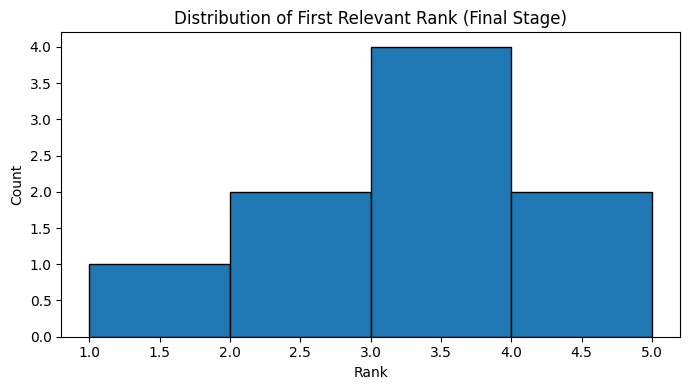

In [10]:
failures = [r for r in records if r["stage_failure"] != "OK"]
failures_sorted = sorted(
    failures,
    key=lambda x: (x["rank_final"] is not None, x["rank_final"] if x["rank_final"] is not None else 9999),
)

print(f"Total failures: {len(failures_sorted)}")
for r in failures_sorted[:10]:
    print("-" * 100)
    print(f"#{r['idx']} | failure={r['stage_failure']}")
    print(f"paper_type={r['paper_type']} | question_type={r['question_type']} | section={r['section_title']}")
    print(f"Q: {r['query_raw']}")
    print(f"relevant_ids: {r['relevant_ids']}")
    print(f"doc_unscoped[:5]: {r['doc_unscoped_ids'][:5]}")
    print(f"section_prerank[:5]: {r['section_prerank_ids'][:5]}")
    print(f"final[:5]: {r['final_ids'][:5]}")

rank_vals = [r["rank_final"] for r in records if r["rank_final"] is not None]
if matplotlib is not None:
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 4))
    if rank_vals:
        plt.hist(rank_vals, bins=range(1, max(rank_vals) + 2), edgecolor="black")
    plt.title("Distribution of First Relevant Rank (Final Stage)")
    plt.xlabel("Rank")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
else:
    print("matplotlib not available; skipping histogram.")

## 9) Compare Configurations and Export Evaluation Reports

This section runs small parameter sweeps (top-k and reranker on/off), summarizes metrics, and exports JSON/CSV reports with stage-level findings.

In [ ]:
def run_config_eval(top_k: int, use_rerank: bool, sample_rows: list[dict[str, Any]]) -> dict[str, Any]:
    tmp_records: list[dict[str, Any]] = []
    for row in sample_rows:
        q = normalize_query(str(row.get("question", "")))
        doc_id = str(row.get("document_id", ""))
        section_id = str(row.get("section_id", ""))
        relevant = {str(x) for x in row.get("relevant_chunk_ids", [])}

        pre = pipeline.retrieve_with_section_scope(
            query=q,
            section_id=section_id,
            document_id=doc_id,
            top_k=top_k,
            top_n=top_k,
            rerank=False,
        )
        post = pipeline.retrieve_with_section_scope(
            query=q,
            section_id=section_id,
            document_id=doc_id,
            top_k=top_k,
            top_n=min(5, top_k),
            rerank=use_rerank,
        )

        pre_ids, _ = extract_ids_scores(pre)
        post_ids, _ = extract_ids_scores(post)
        tmp_records.append(
            {
                "relevant_ids": sorted(relevant),
                "pre_ids": pre_ids,
                "post_ids": post_ids,
            }
        )

    pre_m = {
        "Recall@5": sum(recall_at_k(r["pre_ids"], set(r["relevant_ids"]), 5) for r in tmp_records) / len(tmp_records),
        "MRR": sum(mrr(r["pre_ids"], set(r["relevant_ids"])) for r in tmp_records) / len(tmp_records),
    }
    post_m = {
        "Recall@5": sum(recall_at_k(r["post_ids"], set(r["relevant_ids"]), 5) for r in tmp_records) / len(tmp_records),
        "MRR": sum(mrr(r["post_ids"], set(r["relevant_ids"])) for r in tmp_records) / len(tmp_records),
    }
    return {
        "top_k": top_k,
        "rerank": use_rerank,
        "pre": pre_m,
        "post": post_m,
        "delta_recall5": post_m["Recall@5"] - pre_m["Recall@5"],
        "delta_mrr": post_m["MRR"] - pre_m["MRR"],
    }


sweep_rows = rows[: min(len(rows), 30)]
sweep_configs = [(10, False), (10, True), (20, False), (20, True)]
sweep_results = [run_config_eval(k, rr, sweep_rows) for k, rr in sweep_configs]

if pd is not None:
    display(pd.DataFrame(sweep_results))
else:
    print(json.dumps(sweep_results, indent=2))

report_json_path = OUT_DIR / "retrieval_diagnosis_report.json"
report_records_path = OUT_DIR / "retrieval_diagnosis_records.json"
report_sweep_path = OUT_DIR / "retrieval_diagnosis_config_sweep.json"

final_report = {
    "summary_metrics": summary_table,
    "failure_counts": dict(Counter(r["stage_failure"] for r in records)),
    "largest_loss_stage": Counter(r["stage_failure"] for r in records).most_common(1)[0][0] if records else "N/A",
    "config": CONFIG,
}

with report_json_path.open("w", encoding="utf-8") as f:
    json.dump(final_report, f, indent=2, ensure_ascii=False)
with report_records_path.open("w", encoding="utf-8") as f:
    json.dump(records, f, indent=2, ensure_ascii=False)
with report_sweep_path.open("w", encoding="utf-8") as f:
    json.dump(sweep_results, f, indent=2, ensure_ascii=False)

print(f"Saved summary report: {report_json_path}")
print(f"Saved per-query records: {report_records_path}")
print(f"Saved config sweep: {report_sweep_path}")

if pd is not None:
    # Optional CSV exports when pandas is available.
    pd.DataFrame(records).to_csv(OUT_DIR / "retrieval_diagnosis_records.csv", index=False)
    pd.DataFrame(sweep_results).to_csv(OUT_DIR / "retrieval_diagnosis_config_sweep.csv", index=False)
    print("Saved CSV exports as well.")

INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers/points/query "HTTP/1.1 200 OK"
INFO:rag.retrieval.search.hybrid_retriever:HybridRetriever: query='What are the two main results presented in this paper?' → 10 results (doc_filter=30c88170-fd15-5486-bf70-bbab16747183)
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://b9c1abff-fc0c-4fba-8838-f0890f5b091f.us-east4-0.gcp.cloud.qdrant.io:6333/collections/research_papers "HTTP/1.1 200 OK"
INFO:httpx:HTTP Requ

,top_k,rerank,pre,post,delta_recall5,delta_mrr
0,10,False,"{'Recall@5': 0.13333333333333333, 'MRR': 0.1275}","{'Recall@5': 0.13333333333333333, 'MRR': 0.164...",0.000000,0.036667
1,10,True,"{'Recall@5': 0.13333333333333333, 'MRR': 0.144...","{'Recall@5': 0.12222222222222222, 'MRR': 0.109...",-0.011111,-0.034722
2,20,False,"{'Recall@5': 0.13333333333333333, 'MRR': 0.179...","{'Recall@5': 0.13333333333333333, 'MRR': 0.162...",0.000000,-0.016667
3,20,True,"{'Recall@5': 0.13333333333333333, 'MRR': 0.129...","{'Recall@5': 0.1111111111111111, 'MRR': 0.1083...",-0.022222,-0.021085


Saved summary report: /home/aman/storage/Python/Projects/Research Paper Assistant/backend/evaluation/results/retrieval_diagnosis_report.json
Saved per-query records: /home/aman/storage/Python/Projects/Research Paper Assistant/backend/evaluation/results/retrieval_diagnosis_records.json
Saved config sweep: /home/aman/storage/Python/Projects/Research Paper Assistant/backend/evaluation/results/retrieval_diagnosis_config_sweep.json
Saved CSV exports as well.


: 